# Peanut source

RA: 02 18 06.3604

DEC: +42 32 17.365

GLON: 139.5080912

GLAT: -17.5268286

DISTANCE: 3.15+0.85-0.60 kpc from Earth [Verbiest, Lormier, 2014 (10.1093/mnras/stu1560)].

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from config.settings import DATA_DIR

## Experimental data

### LHAASO

In [4]:
data = pd.read_csv(f"{DATA_DIR}/peanut/spectrum.csv")
data.head()

,Energy,Flux,Index,Type
0,14.059548,2.318720e-13,0,Data
1,14.214927,1.267176e-13,0,Upper
2,14.214927,1.267176e-13,0,Lower
3,22.063551,2.752430e-13,1,Data
4,22.185134,3.633153e-13,1,Upper


In [5]:
data_data = (data[data["Type"] == "Data"][["Energy", "Flux"]]).reset_index(drop=True)
data_upper = (data[data["Type"] == "Upper"][["Flux"]]).reset_index(drop=True)
data_lower = (data[data["Type"] == "Lower"][["Flux"]]).reset_index(drop=True)

In [6]:
data_data["Upper"] = np.abs(data_upper["Flux"] - data_data["Flux"])
data_data["Lower"] = np.abs(data_data["Flux"] - data_lower["Flux"])
data_data["Uplims"] = data_upper["Flux"] < data_data["Flux"]


flux = data_data
flux

,Energy,Flux,Upper,Lower,Uplims
0,14.059548,2.318720e-13,1.051544e-13,1.051544e-13,True
1,22.063551,2.752430e-13,8.807228e-14,8.772213e-14,False
2,35.199734,1.714125e-13,4.227897e-14,4.155259e-14,False
3,50.036164,1.756632e-13,2.615693e-14,2.524344e-14,False
4,78.954103,1.341713e-13,2.251662e-14,1.738929e-14,False
5,125.271428,1.363803e-13,1.527268e-14,1.767559e-14,False
6,199.855448,9.066649e-14,1.608373e-14,1.302910e-14,False
7,317.097865,6.278738e-14,1.548653e-14,1.364124e-14,False
8,443.381985,3.878399e-14,1.768019e-14,1.341780e-14,False
9,703.485856,1.728179e-14,1.592880e-14,1.057922e-14,False


In [7]:
import astropy.units as u

from inverse_compton.attenuation_cmb import get_extinction_by_CMB

flux_unit = 1/(u.cm**2 * u.s)
eflux_unit_erg = u.erg * flux_unit
eflux_unit_TeV = u.TeV * flux_unit

#### LHAASO gamma-ray extinction

In [8]:
D = 3.5 * u.kpc

flux_energy_eV = (np.array(flux.Energy) * u.TeV).to(u.eV)

extinction = get_extinction_by_CMB(flux_energy_eV[:, None], D)

extinction.shape

(11,)

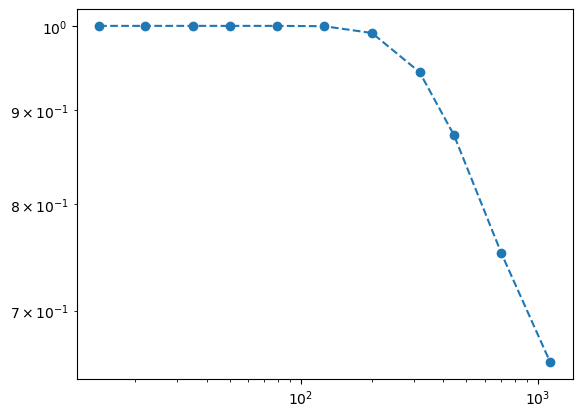

In [9]:
plt.loglog(flux.Energy, 1/extinction, marker='o', linestyle='dashed')
plt.show()

In [10]:
flux.columns.to_list()

['Energy', 'Flux', 'Upper', 'Lower', 'Uplims']

In [11]:
# construct a new flux table
data_mod = np.array([
    flux_energy_eV,
    np.array(flux.Flux) * eflux_unit_TeV * extinction,
    np.array(flux.Upper) * eflux_unit_TeV * extinction,
    np.array(flux.Lower) * eflux_unit_TeV * extinction,
    np.array(flux.Uplims, dtype=np.bool)
    ])

flux_mod = pd.DataFrame(data_mod.T, columns=flux.columns.to_list())

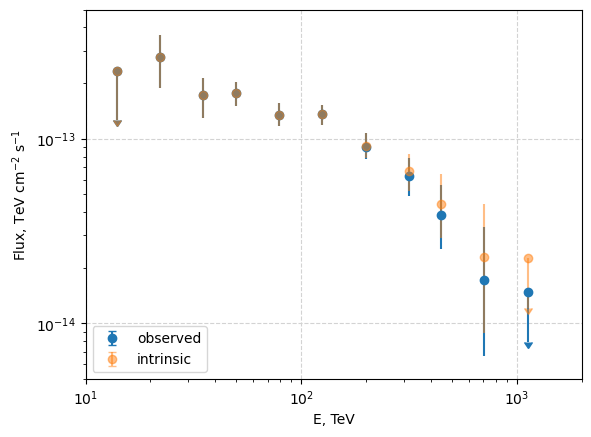

In [12]:
plt.errorbar(flux.Energy, flux.Flux,
             yerr=[flux.Lower, flux.Upper], uplims=flux.Uplims,
             fmt='o',
             label='observed')

plt.errorbar(flux_mod.Energy / 1e12, flux_mod.Flux,
             yerr=[flux_mod.Lower, flux_mod.Upper], uplims=flux_mod.Uplims,
             fmt='o', alpha=0.5,
             label='intrinsic')

plt.xlim(1e1, 2e3)
plt.xscale('log')
plt.xlabel("E, TeV")

plt.ylim(5e-15, 5e-13)
plt.yscale('log')
plt.ylabel(r"Flux, $\mathrm{TeV~cm^{-2}~s^{-1}}$")

plt.grid(color='lightgrey', linestyle='dashed')
plt.legend(loc=3)
plt.show()

### Fermi-LAT and MAGIC

In [13]:
fermi_lat_data = pd.read_csv("./data/peanut/fermi_lat_data.csv")

tev_to_erg = (1 * eflux_unit_TeV).to_value(eflux_unit_erg)

fermi_lat_data.Energy *= 1e9  # [GeV] -> [eV]
fermi_lat_data.Flux *= tev_to_erg
fermi_lat_data.FluxErr *= tev_to_erg

magic_data = pd.read_csv("./data/peanut/magic_data.csv")

magic_data.Energy *= 1e9  # [GeV] -> [eV]
magic_data.Flux *= tev_to_erg
magic_data.FluxErr *= tev_to_erg

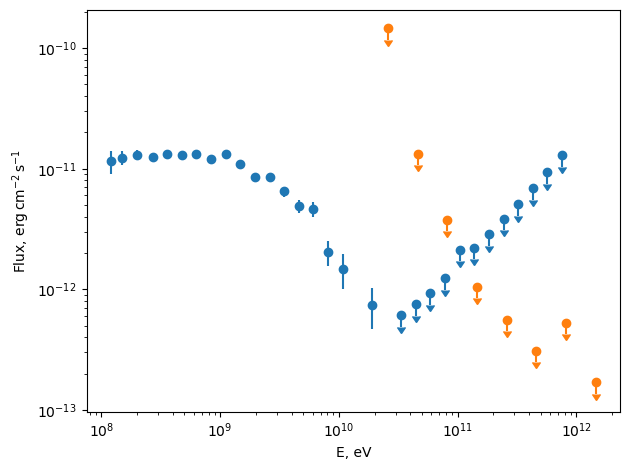

In [14]:
plt.errorbar(fermi_lat_data.Energy, fermi_lat_data.Flux,
             yerr=fermi_lat_data.FluxErr, uplims=fermi_lat_data.Uplims,
             fmt='o')

plt.errorbar(magic_data.Energy, magic_data.Flux,
             yerr=magic_data.FluxErr, uplims=magic_data.Uplims,
             fmt='o')

plt.xscale('log')
plt.xlabel("E, eV")
plt.yscale('log')
plt.ylabel(r"Flux, $\mathrm{erg\,cm^{-2}\,s^{-1}}$")

plt.tight_layout()
plt.show()

## Log-likelihood fit

### Electron configuration

$$ dN/dE = N_0\exp\{\eta - p\ln(E/E_\mathrm{ref}) - E/(E_\mathrm{ref}\times10^{\kappa})\} $$

In [15]:
E_ref = 1 * u.TeV
N0 = 1e45 * u.TeV**(-1)
def electron_spectrum(E, eta, p, k1, k2):
    return N0 * np.exp(eta - p * np.log(E/E_ref) - E / (E_ref * 10**k2)) * np.heaviside((E - E_ref * 10**k1).to_value(u.TeV), 0.5)

In [16]:
from config.constants import CST_m_e

In [67]:
from inverse_compton.klein_nishina import klein_nishina_on_CMB

background_energy = np.logspace(-9, -1, 300) * u.eV
gamma_ray_energy = np.array(flux_mod.Energy) * u.eV  # in eV already
gamma_ray_energy2 = (np.logspace(-6, 5, 400) * u.TeV).to(u.eV)
electron_energy = np.logspace(-3, 5, 200) * u.TeV  # 1 TeV to 10 PeV
gamma = (electron_energy / CST_m_e).to('')  # [DL]

model_on_cmb = np.zeros([gamma_ray_energy.size, electron_energy.size]) * 1/(u.eV * u.s)
model_on_cmb2 = np.zeros([gamma_ray_energy2.size, electron_energy.size]) * 1/(u.eV * u.s)

for j, g in enumerate(gamma):
    model_on_cmb[:, j] = klein_nishina_on_CMB(g, gamma_ray_energy, background_energy)
    model_on_cmb2[:, j] = klein_nishina_on_CMB(g, gamma_ray_energy2, background_energy)

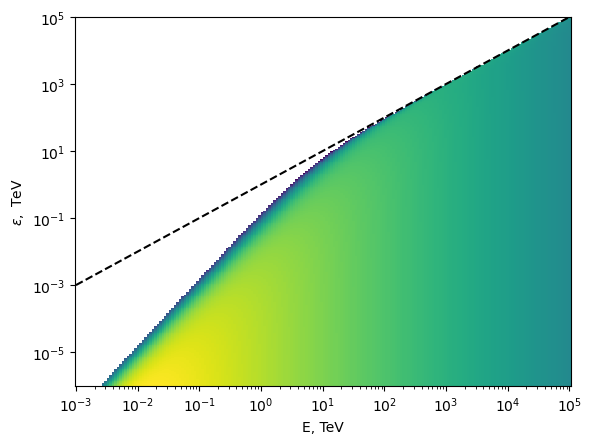

In [68]:
plt.pcolormesh(electron_energy.to_value(u.TeV), gamma_ray_energy2.to_value(u.TeV), model_on_cmb2.value, norm='log')
plt.plot(electron_energy.to_value(u.TeV), electron_energy.to_value(u.TeV), color='black', linestyle='dashed')
plt.xscale('log')
plt.xlabel("E, TeV")
plt.yscale('log')
plt.ylabel(r"$\epsilon,$ TeV")
plt.show()

In [69]:
def model(eta, p, k1, k2):
    return (gamma_ray_energy**2 * np.trapezoid(electron_spectrum(electron_energy, eta, p, k1, k2) * model_on_cmb, electron_energy) / (4*np.pi * D**2)).to(eflux_unit_TeV)

def model2(eta, p, k1, k2):
    return (gamma_ray_energy2**2 * np.trapezoid(electron_spectrum(electron_energy, eta, p, k1, k2) * model_on_cmb2, electron_energy) / (4*np.pi * D**2)).to(eflux_unit_TeV)

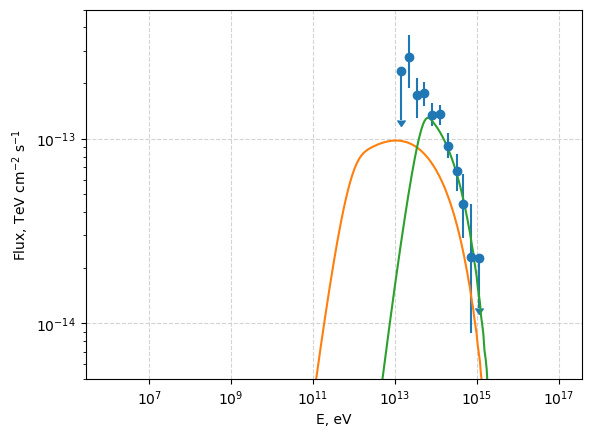

In [70]:
plt.errorbar(flux_mod.Energy, flux_mod.Flux,
             yerr=[flux_mod.Lower, flux_mod.Upper], uplims=flux_mod.Uplims,
             fmt='o', )

plt.loglog(gamma_ray_energy2.to(u.eV), model2(1.0, 2.5, 1.0, 3.0))
plt.loglog(gamma_ray_energy2.to(u.eV), model2(1.0, 2.4, 2.0, 3.0))
plt.grid(color='lightgrey', linestyle='dashed')


plt.xscale('log')
plt.xlabel("E, eV")

plt.ylim(5e-15, 5e-13)
plt.yscale('log')
plt.ylabel(r"Flux, $\mathrm{TeV~cm^{-2}~s^{-1}}$")

plt.show()

In [71]:
from src.likelihood_elements import log_likelihood_measurements
### log-likelihood

f, lower, upper, uplims = np.array(flux_mod.Flux) * eflux_unit_TeV, np.array(flux_mod.Lower) * eflux_unit_TeV, np.array(flux_mod.Upper) * eflux_unit_TeV, np.bool_(flux_mod.Uplims)

def log_likelihood_model(params, k1=0.0):
    model_flux = model(params[0], params[1], k1, params[2])
    return -log_likelihood_measurements(f, lower, upper, uplims, model_flux)

In [22]:
print(log_likelihood_model((0.0, 2.5, 3.0), 0.0))
print(log_likelihood_model((1.0, 2.4, 3.0), 0.0))

183.17274914146117
7.820016610497565


In [23]:
from scipy.optimize import minimize

pm = minimize(log_likelihood_model, x0=(1.0, 2.5, 3.0))
pm

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 1.9731686183408859
        x: [ 1.908e+00  2.530e+00  2.943e+00]
      nit: 15
      jac: [ 4.411e-06 -2.940e-05  8.062e-06]
 hess_inv: [[ 2.304e+00  4.999e-01  5.718e-01]
            [ 4.999e-01  1.089e-01  1.267e-01]
            [ 5.718e-01  1.267e-01  1.605e-01]]
     nfev: 235
     njev: 56

In [24]:
flat_s = pd.read_csv(DATA_DIR / "flat_sensitivity.csv")
print(flat_s.columns)

flat_e = np.array(flat_s["E(MeV)"]) * u.MeV
flat_s = np.array(flat_s["Flux(erg.cm-2.s-1)"]) * eflux_unit_erg

Index(['E(MeV)', 'Flux(erg.cm-2.s-1)'], dtype='object')


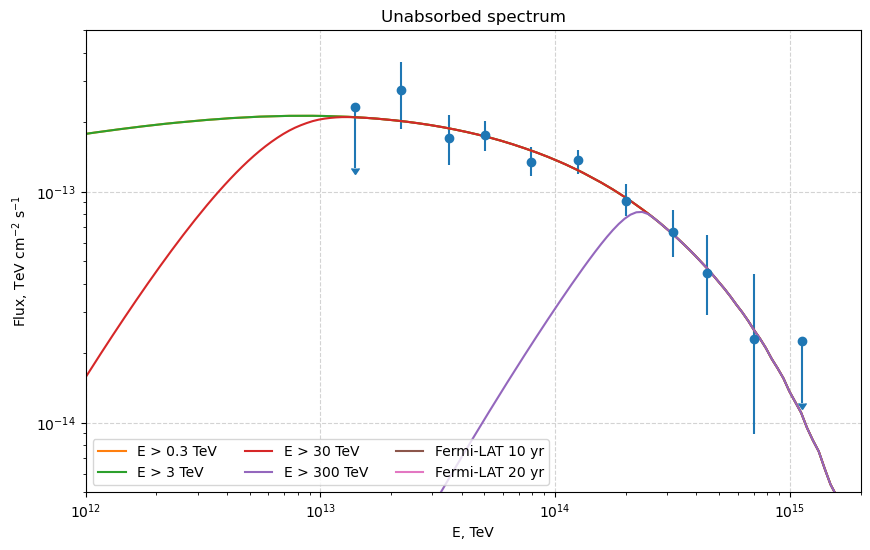

In [25]:
plt.figure(figsize=(10, 6))
plt.errorbar(flux_mod.Energy, flux_mod.Flux,
             yerr=[flux_mod.Lower, flux_mod.Upper], fmt='o', uplims=flux_mod.Uplims)

pp = pm.x
for e1 in [0.3, 3, 30, 300]:
    plt.plot(gamma_ray_energy2.to_value(u.eV), model2(pp[0], pp[1], np.log10(e1), pp[2]), label=f"E > {e1} TeV")
    
plt.plot(flat_e.to_value(u.eV), flat_s.to_value(eflux_unit_TeV), label="Fermi-LAT 10 yr")
plt.plot(flat_e.to_value(u.eV), flat_s.to_value(eflux_unit_TeV) / np.sqrt(2), label="Fermi-LAT 20 yr")

plt.xlim(1e12, 2e15)
plt.xscale('log')
plt.xlabel("E, TeV")

plt.ylim(5e-15, 5e-13)
plt.yscale('log')
plt.ylabel(r"Flux, $\mathrm{TeV~cm^{-2}~s^{-1}}$")

plt.legend(loc=3, ncol=3)

plt.grid(color='lightgrey', linestyle='dashed')
plt.title("Unabsorbed spectrum")
plt.show()

## Peanut Parameter Space

In [26]:
from config.units import uGauss

angles = np.linspace(0, 180, 180, endpoint=True) * u.deg
fields = np.logspace(-2, 2, 100) * uGauss

ab = angles[:, None]
ba = fields[None, :]

Rectangle angular size (LHAASO article): $4.6^\circ \times 0.45^\circ$

Length: $L = D \times \theta$

In [27]:
ang_size = 4.6 * u.deg
L = (D * ang_size.to_value(u.rad)).to(u.pc)
print(f"{L:.1f}")

281.0 pc


### Free streaming regime

#### Propagation time

$\tau_\mathrm{prop} = \dfrac{281~\mathrm{pc}}{\sin\alpha}\times\dfrac{1}{c\cos\alpha} \approx \dfrac{1.8~\mathrm{kyr}}{\sin2\alpha}$

In [28]:
print(f"{(2 * 281 * u.pc / (3e8 * u.m/u.s)).to(u.yr):.1f}")

1831.7 yr


In [29]:
free_streaming_time = (1.8 * u.kyr / np.sin(2 * ab)).to(u.kyr)
mean_time = (281 * u.pc / np.sin(ab) / (3e8*u.m/u.s)).to(u.kyr)  # c/3

/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


### Diffuse propagation

#### Propagation time

Length: $L = \dfrac{281~\mathrm{pc}}{\sin\alpha}$

Diffusion coefficient: $D_\parallel \sim 10^{30}~\mathrm{\dfrac{cm^2}{s}} \left(\dfrac{B}{\delta B}\right)^2 \left(\dfrac{E}{\mathrm{PeV}}\right)^{2-s} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{s-2} = 3.3\times10^{3}~\mathrm{\dfrac{pc^2}{kyr}} \left(\dfrac{B}{\delta B}\right)^2 \left(\dfrac{E}{\mathrm{PeV}}\right)^{2-s} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{s-2}$

In [30]:
print(f"{(1e30 * u.cm**2/u.s).to(u.pc**2/u.kyr):.1f}")

3314.4 pc2 / kyr


In [31]:
print(f"{((281*u.pc)**2/(4e30 * u.cm**2/u.s)).to(u.kyr):.1f}")

6.0 kyr


Diffusion timescale: $\tau_\mathrm{diff} = L^2/4D_\parallel \sim 6~\mathrm{kyr} \left(\dfrac{B_0}{\delta B}\right)^{-2} \left(\dfrac{E}{\mathrm{PeV}}\right)^{s-2} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{2-s}\times (\sin\alpha)^{-2}$

In [32]:
s = 5/3
def diffusion_time(b, ang, i, delta=1.0, s=5/3):
    return (6 * u.kyr) * (1/delta)**(-2) * (electron_energy[i] / u.PeV)**(s-2) * (b/uGauss)**(2-s) * np.sin(ang)**(-2)

In [33]:
mfp = np.zeros_like(electron_energy.value) * u.pc

### Cooling timescales

**Synchrotron**

$\tau_\mathrm{syn} = 8.35~\mathrm{kyr}~\left(\dfrac{B}{\mathrm{\mu G}}\right)^{-2} \left(\sin\alpha\right)^{-2} \left(\dfrac{E}{\mathrm{PeV}}\right)^{-1}$

In [34]:
def synch_time(b, ang, E):
    return (8.35 * u.kyr * (b/uGauss)**(-2) * np.sin(ang)**(-2) * (E/u.PeV)**(-1)).to(u.kyr)

**Inverse Compton**

$\epsilon'_\mathrm{max} = 2\gamma\epsilon = 2E\epsilon/m_ec^2$

Regimes (Thomson & Klein-Nishina) are defined by comparing $\epsilon'$ with $m_ec^2$.

Or $E$ with $(m_ec^2)^2/2\epsilon$. For CMB ($\epsilon = 6.3\times10^{-4}~\mathrm{eV}$), $E_\mathrm{T->KN} \sim 200\mathrm{TeV}$$

In [35]:
import astropy.constants.codata2010 as cst
from config.constants import E_CMB, T_CMB, CST_m_e, CST_r0
print(f"{E_CMB:.2g}, {T_CMB}")

print(f"Transition: {(CST_m_e**2 / (2 * E_CMB)).to(u.TeV):.1f}")

0.00063 eV, 2.72548 K
Transition: 205.8 TeV


1. Thomson regime ($\epsilon'\ll m_ec^2,~E\ll200~\mathrm{TeV}$)

    $\tau_\mathrm{TH} = \dfrac{E}{\dot{E}} = \dfrac{3(m_ec^2)^2}{4\sigma_Tc\mathcal{E}_\mathrm{iso}}\dfrac{1}{E},$

    where $\mathcal{E}_\mathrm{iso} = \int \epsilon n_\epsilon(T) d\epsilon = aT^4 = \dfrac{4\sigma_*}{c}T^4$

    $\tau_\mathrm{TH} = \dfrac{E}{\dot{E}} = 120~\mathrm{kyr}\left(\dfrac{E}{\mathrm{10~TeV}}\right)^{-1},$

In [36]:
print((3 * CST_m_e**2 / (4 * cst.sigma_T * 4 * cst.sigma_sb * T_CMB**4) / (10 * u.TeV)).to(u.kyr))

119.42132878025518 kyr


2. Extreme Klein-Nishina limit

    $\tau_\mathrm{ExKN} = \dfrac{E}{\dot{E}} = \dfrac{6\hbar^3E}{\pi r_0^2(m_eckT)^2}\left[\ln\dfrac{4EkT}{(m_ec^2)^2} - 5/6 - C_E - C_l\right]^{-1}$,

    which with $C_E = 0.5772,$ $C_l = 0.5700$ is close to $\ln\dfrac{EkT}{1.8(m_ec^2)^2}$.

    $\tau_\mathrm{ExKN} = \dfrac{E}{\dot{E}} = 84~\mathrm{kyr}~\left(\dfrac{E}{\mathrm{10~PeV}}\right)\left[\ln\dfrac{E}{2~\mathrm{PeV}}\right]^{-1}$

In [46]:
cst_sum = 5/6 + 0.5772 + 0.5700
print(cst_sum)
print(np.exp(cst_sum))
print(7.246/4)

1.9805333333333333
7.246606811681916
1.8115


In [78]:
def extreme_klein_nishina_time(E):
    return (6 * cst.hbar**3 * E / (np.pi * CST_r0**2 * (CST_m_e/cst.c * cst.k_B * T_CMB)**2 * (np.log((4 * E * cst.k_B * T_CMB)/(CST_m_e)**2) - cst_sum)**(-1))).to(u.kyr)

In [79]:
print(extreme_klein_nishina_time(6*u.PeV))
print(((1.8 * CST_m_e**2) / (cst.k_B * T_CMB)).to(u.PeV))
135.6 / 1.61

88.81657071754631 kyr
2.0012285735155046 PeV


84.22360248447204

### Actual values

In [62]:
Edot_KN = np.trapezoid(model_on_cmb2 * gamma_ray_energy2[:, None], gamma_ray_energy2, axis=0)
time_KN = (electron_energy / Edot_KN).to(u.kyr)

/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [72]:
def total_loss_time(b, ang):
    return (1/synch_time(b, ang, electron_energy) + 1/time_KN)**(-1)

def total_loss_time_i(b, ang, i):
    return (1/synch_time(b, ang, electron_energy[i]) + 1/time_KN[i])**(-1)

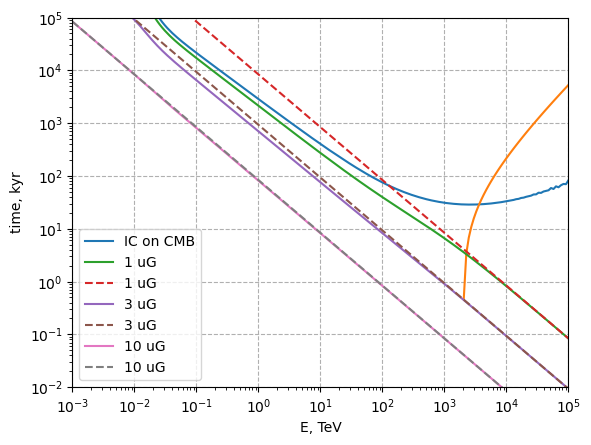

In [80]:
plt.loglog(electron_energy, time_KN, label='IC on CMB')

e_high = electron_energy[electron_energy > 2 * u.PeV]
plt.loglog(e_high, extreme_klein_nishina_time(e_high))

plt.loglog(electron_energy, total_loss_time(1*uGauss, 90*u.deg), label='1 uG')
plt.loglog(electron_energy, synch_time(1*uGauss, 90*u.deg, electron_energy), label='1 uG', linestyle='dashed')

plt.loglog(electron_energy, total_loss_time(3*uGauss, 90*u.deg), label='3 uG')
plt.loglog(electron_energy, synch_time(3*uGauss, 90*u.deg, electron_energy), label='3 uG', linestyle='dashed')

plt.loglog(electron_energy, total_loss_time(10*uGauss, 90*u.deg), label='10 uG')
plt.loglog(electron_energy, synch_time(10*uGauss, 90*u.deg, electron_energy), label='10 uG', linestyle='dashed')

plt.xlabel("E, TeV")
plt.xlim(1e-3, 1e5)

plt.ylim(1e-2, 1e5)
plt.ylabel("time, kyr")

plt.grid(linestyle='dashed')
plt.legend()
plt.show()

### Summary plot

In [40]:
i_700 = 167
i_500 = 162

loss_time = total_loss_time_i(ba, ab, i_500)

/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [41]:
# free_streaming
fs_limit = (free_streaming_time - loss_time).to_value(u.kyr) * (free_streaming_time > 0) + (free_streaming_time < 0)

In [42]:
# diffusion
dif_time_01 = diffusion_time(ba, ab, i_500, delta=0.1)
dif_time_03 = diffusion_time(ba, ab, i_500, delta=0.3)
dif_time_1 = diffusion_time(ba, ab, i_500, delta=1.0)

dif_limit_01 = (dif_time_01 - loss_time).to_value(u.kyr)
dif_limit_03 = (dif_time_03 - loss_time).to_value(u.kyr) 
dif_limit_1 = (dif_time_1 - loss_time).to_value(u.kyr)

dif_fs_limit_01 = (mean_time - dif_time_01).to_value(u.kyr)  # negative when diffusion is allowed
dif_fs_limit_03 = (mean_time - dif_time_03).to_value(u.kyr)  # negative when diffusion is allowed
dif_fs_limit_1 = (mean_time - dif_time_1).to_value(u.kyr) # negative when diffusion is allowed

/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in subtract
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [43]:
f_gs = fields.to_value(uGauss)
ang_deg = angles.to_value(u.deg)

/tmp/ipykernel_6656/3947711207.py:3: UserWarning: The following kwargs were not used by contour: 'linecolors'
  pm = ax.contourf(f_gs, ang_deg, fs_limit, levels=[-1000, 0], linecolors=['green'], colors=['green'], alpha=.2)


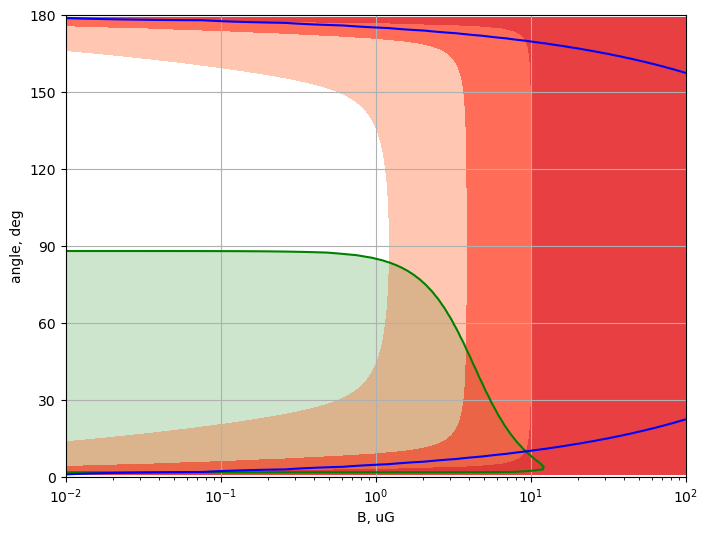

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

pm = ax.contourf(f_gs, ang_deg, fs_limit, levels=[-1000, 0], linecolors=['green'], colors=['green'], alpha=.2)
pm = ax.contour(f_gs, ang_deg, fs_limit, levels=[0, 1000], colors=['green'])
pm2 = ax.contourf(f_gs, ang_deg, dif_limit_01, levels=[0, 1e8], colors=['purple'], alpha=0.5)
pm2 = ax.contourf(f_gs, ang_deg, dif_limit_03, levels=[0, 1e8], colors=['red'], alpha=0.5)
pm3 = ax.contourf(f_gs, ang_deg, dif_limit_1, levels=[0, 1e8], colors=['orangered'], alpha=0.3)

pm4 = ax.contour(f_gs, ang_deg, dif_fs_limit_01, levels=[0, 1000], colors=['blue'], alpha=1.0)
# pm4 = ax.contourf(f_gs, ang_deg, dif_fs_limit_01, levels=[0, 1000], colors=['blue'], alpha=0.2)
pm4 = ax.contour(f_gs, ang_deg, dif_fs_limit_1, levels=[0, 1000], colors=['black'], alpha=1.0)
pm4 = ax.contourf(f_gs, ang_deg, dif_fs_limit_1, levels=[0, 1000], colors=['black'], alpha=0.3)

ax.set_xlabel("B, uG")
ax.set_xscale('log')
ax.set_xlim(1e-2, 1e2)
# ax.set_yscale('log')
ax.set_ylabel("angle, deg")
ax.set_ylim(0, 180)
ax.set_yticks([0, 30, 60, 90, 120, 150, 180])
ax.grid(True)

plt.show()

In [45]:
ang_plot = (angles - 90 * u.deg).to_value(u.rad)
f_plot = fields.to_value(uGauss)

/tmp/ipykernel_6656/1776675315.py:9: RuntimeWarning: invalid value encountered in multiply
  ax.contourf(ang_plot, f_plot, (dif_limit_01 * (dif_fs_limit_01 < 0) + (dif_fs_limit_01 > 0)).T, levels=[-1e36, 0], colors=['orangered'], alpha=0.2)
/tmp/ipykernel_6656/1776675315.py:12: RuntimeWarning: invalid value encountered in multiply
  ax.contourf(ang_plot, f_plot, (dif_limit_03 * (dif_fs_limit_03 < 0) + (dif_fs_limit_03 > 0)).T, levels=[-1e36, 0], colors=['red'], alpha=0.3)
/tmp/ipykernel_6656/1776675315.py:15: RuntimeWarning: invalid value encountered in multiply
  ax.contourf(ang_plot, f_plot, (dif_limit_1 * (dif_fs_limit_1 < 0) + (dif_fs_limit_1 > 0)).T, levels=[-1e36, 0], colors=['purple'], alpha=0.4)


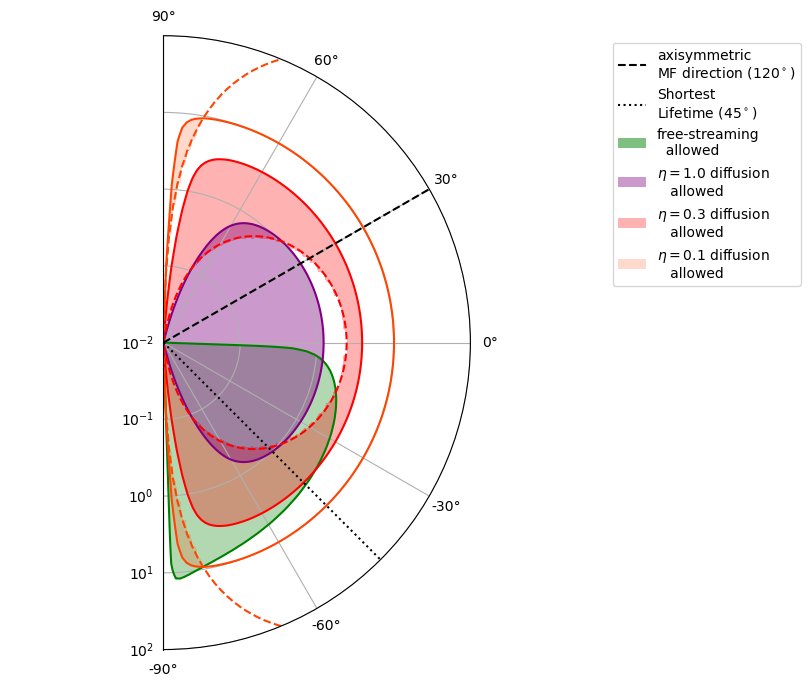

In [46]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': 'polar'}, layout='compressed')

ax.contourf(ang_plot, f_plot, fs_limit.T, levels=[-1e8, 0], colors=['green'], alpha=0.3)
ax.contour(ang_plot, f_plot, fs_limit.T, levels=[-1e8, 0], colors=['green'])

ax.contour(ang_plot, f_plot, dif_limit_01.T, levels=[-1e36, 0], colors=['orangered'])
ax.contourf(ang_plot, f_plot, (dif_limit_01 * (dif_fs_limit_01 < 0) + (dif_fs_limit_01 > 0)).T, levels=[-1e36, 0], colors=['orangered'], alpha=0.2)

ax.contour(ang_plot, f_plot, dif_limit_03.T, levels=[-1e36, 0], colors=['red'])
ax.contourf(ang_plot, f_plot, (dif_limit_03 * (dif_fs_limit_03 < 0) + (dif_fs_limit_03 > 0)).T, levels=[-1e36, 0], colors=['red'], alpha=0.3)

ax.contour(ang_plot, f_plot, dif_limit_1.T, levels=[-1e36, 0], colors=['purple'])
ax.contourf(ang_plot, f_plot, (dif_limit_1 * (dif_fs_limit_1 < 0) + (dif_fs_limit_1 > 0)).T, levels=[-1e36, 0], colors=['purple'], alpha=0.4)

ax.contour(ang_plot, f_plot, dif_fs_limit_01.T, levels=[ 0], colors=['orangered'], linestyles=['dashed'])
ax.contour(ang_plot, f_plot, dif_fs_limit_03.T, levels=[0], colors=['red'], linestyles=['dashed'])
ax.contour(ang_plot, f_plot, dif_fs_limit_1.T, levels=[0], colors=['purple'], linestyles=['dashed'])

vl1 = ax.vlines([np.deg2rad(30)], 1e-2, 1e2, linestyles=['dashed'], label='axisymmetric\nMF direction 'r'$(120^\circ)$', color='black')
vl2 = ax.vlines([np.deg2rad(-45)], 1e-2, 1e2, linestyles=['dotted'], label='Shortest\nLifetime 'r'$(45^\circ)$', color='black')

ax.set_yscale('log')
ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.grid(True)

legend_elements = [
    vl1, vl2,
    Patch(facecolor='green', alpha=0.5, label='free-streaming\n  allowed'),
    Patch(facecolor='purple', alpha=0.4, label=r'$\eta=1.0$ diffusion''\n   allowed'),
    Patch(facecolor='red', alpha=0.3, label=r'$\eta=0.3$ diffusion''\n   allowed'),
    Patch(facecolor='orangered', alpha=0.2, label=r'$\eta=0.1$ diffusion''\n   allowed')
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.3, 1.0))

plt.show()

## Possible width of the X-ray filament and its detectability 

Consider a cylindrical tube of radius $r$. The local flux per solid angle will be the stronger, the thinner is the filament itself.

### How does an thin filament look in a telescope with angular resolution $\delta$?

Let $n(r, z) = n_0\,\mathbf{1}(r < r_0)\times \mathbf{1}(0 < z < L)$, where $r = \sqrt{x^2 + y^2} $

Then if $y$ is the LoS axis, and all other elements are constant along the MF line,

$I \propto \int dy\, n(r(x,y), z) = n_0\,\mathbf{1}(0 < z < L) \int dy\,\mathbf{1}(\sqrt{x^2 + y^2} < r_0)$

The integral is given by the length of a chord at distance $|x| < r_0$ from the filament:

$ I \propto n_0\,\mathbf{1}(0 < z < L) \times \mathbf{1}(|x| < r_0) \times 2\sqrt{r_0^2 - x^2}$


In [47]:
import numpy as np

xsize, zsize = 400, 600  # [px, px]
x = np.arange(-xsize//2, xsize//2 + 1e-3, 1.0)  # [-xs/2, xs/2]
z = np.arange(-zsize//4, 3 * zsize//4 + 1e-3, 1.0) # [-zs/4, 3zs/4]

xz, zx = np.meshgrid(x, z, indexing='ij')

L = 400  # [px]
r0 = 10  # [px]

intensity_map = np.zeros([x.size, z.size])

intensity_map[np.abs(xz) < r0] = (2 * np.sqrt(r0**2 - xz**2) * (0 < zx) * (zx < L))[np.abs(xz) < r0]

/tmp/ipykernel_6656/1043926918.py:14: RuntimeWarning: invalid value encountered in sqrt
  intensity_map[np.abs(xz) < r0] = (2 * np.sqrt(r0**2 - xz**2) * (0 < zx) * (zx < L))[np.abs(xz) < r0]


In [48]:
from scipy.ndimage import gaussian_filter

delta = 30  # [px]

int_map_sm = gaussian_filter(intensity_map, sigma=delta)

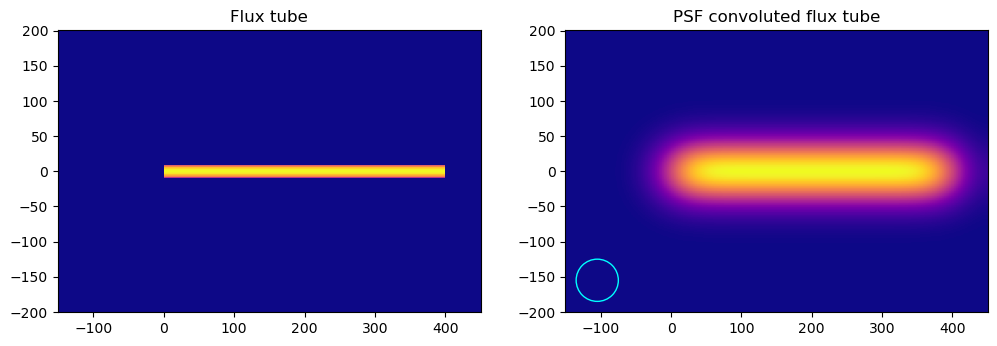

In [49]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


plt.figure(figsize=(12, 4))
ax = plt.subplot(121)
ax.pcolormesh(z, x, intensity_map, cmap='plasma')
ax.set_aspect('equal')
ax.set_title("Flux tube")

ax = plt.subplot(122)
ax.pcolormesh(z, x, int_map_sm, cmap='plasma')
ax.set_aspect('equal')
psf_circ = Circle((z[0] + 1.5 * delta, x[0] + 1.5 * delta), delta, color='cyan', fill=False)
ax.add_patch(psf_circ)
ax.set_title("PSF convoluted flux tube")

plt.show()

### What is the expected X-ray flux from the source?

We are generally interested in the *most conservative* model which satisfies the data => we take the minimal electron distribution required to reproduce the LHAASO measurements

In [50]:
eta0, p0, k10, k20 = pp[0], pp[1], np.log10(30), pp[2]  # eta, p0, 30 TeV, k2 (best-fit)
print(f"Model parameters. Eta = {eta0:.2g}, p0 = {p0:.2f}, e1 = {10**k10:.3g} TeV, e2 = {10**k20:.3g} TeV")

Model parameters. Eta = 1.9, p0 = 2.53, e1 = 30 TeV, e2 = 877 TeV


In [51]:
# GAMMA-RAY RADIATION

cmb_absorption = get_extinction_by_CMB(gamma_ray_energy2[:, None], distance=D)

gamma_ray_model = model2(eta0, p0, k10, k20)
gamma_ray_model_le = model2(eta0, p0, -3, k20)

In [52]:
# SYNCHROTRON RADIATION
from synchrotron.synchrotron_emission import electron_synchrotron_emission_luminosity
from synchrotron.attenuation_photoelectric import photoelectric_optical_depth


xray_energy = np.logspace(-1, 9, 1000) * u.eV
hi_cold = 6.75e20 * u.cm**(-2)

# see section 5.2. of the https://doi.org/10.3847/1538-4357/ab718f
# they say this value is taken directly from HI4PI
# TODO: check this value from HI4PI!!!

pod = photoelectric_optical_depth(xray_energy, hi_cold)

xray_luminosity = electron_synchrotron_emission_luminosity(
    electron_energy=electron_energy,
    electron_density=electron_spectrum(electron_energy, eta0, p0, k10, k20),
    photon_energy=xray_energy,
    bfield=1*uGauss,
    alpha=np.deg2rad(45))
xray_flux = (1/(4*np.pi*D**2) * xray_luminosity * xray_energy).to(eflux_unit_TeV)

xray_luminosity_le = electron_synchrotron_emission_luminosity(
    electron_energy=electron_energy,
    electron_density=electron_spectrum(electron_energy, eta0, p0, -3, k20),
    photon_energy=xray_energy,
    bfield=1*uGauss,
    alpha=np.deg2rad(45))

xray_flux_le = (1/(4*np.pi*D**2) * xray_luminosity_le * xray_energy).to(eflux_unit_TeV)

/home/maxkl/Documents/IP_Paris_M2/APC-project/PWN_Calculation/synchrotron/attenuation_photoelectric.py:8: RuntimeWarning: overflow encountered in exp
  return np.exp(2e-26 * photon_energy.to_value(u.keV)**(-8/3) * hI_column_density.to_value(u.m**(-2)))


In [53]:
xray_luminosity_3uG = electron_synchrotron_emission_luminosity(
    electron_energy=electron_energy,
    electron_density=electron_spectrum(electron_energy, eta0, p0, k10, k20),
    photon_energy=xray_energy,
    bfield=3*uGauss,
    alpha=np.deg2rad(45))
xray_flux_3uG = (1/(4*np.pi*D**2) * xray_luminosity_3uG * xray_energy).to(eflux_unit_TeV)

xray_luminosity_10uG = electron_synchrotron_emission_luminosity(
    electron_energy=electron_energy,
    electron_density=electron_spectrum(electron_energy, eta0, p0, k10, k20),
    photon_energy=xray_energy,
    bfield=10*uGauss,
    alpha=np.deg2rad(45))
xray_flux_10uG = (1/(4*np.pi*D**2) * xray_luminosity_10uG * xray_energy).to(eflux_unit_TeV)

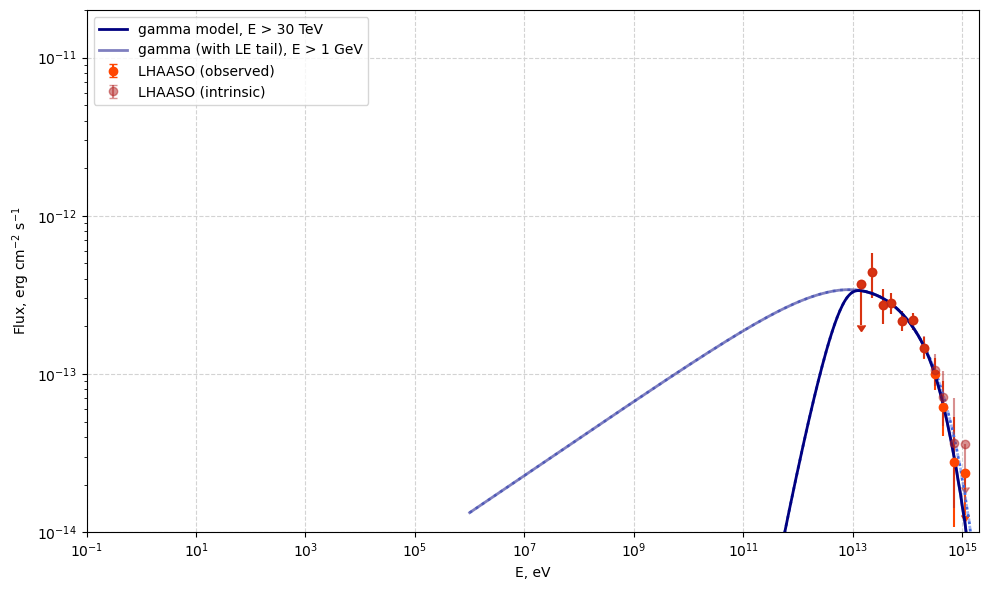

In [63]:
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)

tev_to_erg = (1 * eflux_unit_TeV).to_value(eflux_unit_erg)

def plot_lhaaso(ax):
    # GAMMA-RAY Measurements by LHAASO
    ax.errorbar(flux.Energy * 1e12,
                flux.Flux * tev_to_erg,
                yerr=[flux.Lower * tev_to_erg, flux.Upper * tev_to_erg], uplims=flux.Uplims,
                fmt='o', color='orangered',
                label='LHAASO (observed)')
    ax.errorbar(flux_mod.Energy,
                flux_mod.Flux * tev_to_erg,
                yerr=[flux_mod.Lower * tev_to_erg, flux_mod.Upper * tev_to_erg], uplims=flux_mod.Uplims,
                fmt='o', color='firebrick', alpha=0.5,
                label='LHAASO (intrinsic)')


def plot_gamma_rays(ax):
    # GAMMA-RAY signal
    ax.plot(gamma_ray_energy2.to_value(u.eV),
            gamma_ray_model.to_value(eflux_unit_erg),
            color='royalblue', linewidth=2, linestyle='dotted')
    ax.plot(gamma_ray_energy2.to_value(u.eV),
            gamma_ray_model_le.to_value(eflux_unit_erg),
            color='royalblue', linewidth=2, alpha=0.5, linestyle='dotted')

    ax.plot(gamma_ray_energy2.to_value(u.eV),
            gamma_ray_model.to_value(eflux_unit_erg) / cmb_absorption,
            color='navy', linewidth=2,
            label=f"gamma model, E > {30} TeV")
    ax.plot(gamma_ray_energy2.to_value(u.eV),
            gamma_ray_model_le.to_value(eflux_unit_erg) / cmb_absorption,
            color='navy', linewidth=2, alpha=0.5,
            label=f"gamma (with LE tail), E > {1} GeV")

def plot_xrays(ax):
    # X-RAY signal
    ax.plot(xray_energy.to_value(u.eV),
            xray_flux.to_value(eflux_unit_erg),
            color='seagreen', zorder=10, linewidth=2, linestyle='dotted')
    ax.plot(xray_energy.to_value(u.eV),
            xray_flux_le.to_value(eflux_unit_erg),
            color='seagreen', alpha=.5, linewidth=2, linestyle='dotted')

    ax.plot(xray_energy.to_value(u.eV),
            xray_flux.to_value(eflux_unit_erg) / pod,
            color='seagreen', zorder=10, linewidth=2,
            label=r"x-ray, $45^\circ,~1~\mu G$")
    ax.plot(xray_energy.to_value(u.eV),
            xray_flux_le.to_value(eflux_unit_erg) / pod,
            color='seagreen', alpha=.5, linewidth=2,
            label=r"x-ray (with LE tail), $45^\circ,~1~\mu G$")
    ax.plot(xray_energy.to_value(u.eV),
            xray_flux_3uG.to_value(eflux_unit_erg) / pod,
            color='seagreen', alpha=.5, linewidth=2, linestyle='dashdot',
            label=r"x-ray, $45^\circ,~3~\mu G$")
    ax.plot(xray_energy.to_value(u.eV),
            xray_flux_10uG.to_value(eflux_unit_erg) / pod,
            color='seagreen', alpha=.5, linewidth=2, linestyle='dashed',
            label=r"x-ray, $45^\circ,~10~\mu G$")
    

def plot_powerlaws(ax):
    # THEORETICAL POWERLAWS IN THOMSON LIMIT
    gre_sh = gamma_ray_energy2.to_value(u.eV)[0:250]
    ax.plot(gre_sh,
            gamma_ray_model_le.to_value(eflux_unit_erg)[50] * (gre_sh/gamma_ray_energy2[50])**(-(p0-1)/2 + 1),
            color='black', linestyle='dashdot', alpha=0.5, zorder=0)
    ax.text(1e9, 1e-13, r"$\dfrac{p-1}{2} + 1$", rotation=35, color='black', alpha=0.5)

    xre_sh = xray_energy.to_value(u.eV)[0:400]
    ax.plot(xre_sh,
            xray_flux_le.to_value(eflux_unit_erg)[100] * (xre_sh/xray_energy[100])**(-(p0-1)/2 + 1),
            color='black', linestyle='dashdot', alpha=0.5, zorder=0)
    ax.text(1e1, 3.8e-14, r"$\dfrac{p-1}{2} + 1$", rotation=35, color='black', alpha=0.5)
    
    
def plot_fermi_magic(ax):
        ax.errorbar(fermi_lat_data.Energy, fermi_lat_data.Flux,
             yerr=fermi_lat_data.FluxErr, uplims=fermi_lat_data.Uplims,
             fmt='o', color='pink',
             label='Fermi-LAT (MSP)')

        ax.errorbar(magic_data.Energy, magic_data.Flux,
             yerr=magic_data.FluxErr, uplims=magic_data.Uplims,
             fmt='o', color='purple',
             label='MAGIC (MSP)')


def plot_fermi_uplims(ax):
    # FERMI upper limits
    ax.plot(flat_e.to_value(u.eV),
            flat_s.to_value(eflux_unit_TeV),
            linestyle='dashed', color='black', alpha=.4,
            label="Fermi-LAT Sensitivity 10 yr")
    ax.plot(flat_e.to_value(u.eV),
            flat_s.to_value(eflux_unit_TeV) / np.sqrt(2),
            linestyle='dotted', color='gray', alpha=.6,
            label="Fermi-LAT Sensitivity 20 yr")
    
plot_lhaaso(ax)
plot_gamma_rays(ax)
#plot_xrays(ax)
#plot_powerlaws(ax)
#plot_fermi_magic(ax)

#plot_fermi_uplims(ax)

def adjust_plot(ax):
        ax.set_xlim(1e-1, 2e15)
        ax.set_xscale('log')
        ax.set_xlabel("E, eV")

        ax.set_ylim(1e-14, 2e-11)
        ax.set_yscale('log')
        ax.set_ylabel(r"Flux, $\mathrm{erg~cm^{-2}~s^{-1}}$")

        ax.grid(color='lightgrey', linestyle='dashed')
        
adjust_plot(ax)

plt.legend(loc=2, ncol=1)

plt.tight_layout()
plt.show()

#### **Specific X-ray instruments: Chandra**

If we take, for instance, Chandra (CXO), it can detect x-rays in $[0.5, 8]~\mathrm{keV}$ energy-range.

This is around the radiation maximum from our source...

According to the Chandra website, it has angular resolution of $~0.5''$ and flux sensitivity of $4\times10^{-15}~\mathrm{\dfrac{erg}{cm^2\,s}}$


Hence we need to calculate the integrated flux, deabsorb it taking photoelectric effect on HI into account, and calculate expected flux density (per **sr**) 

In [55]:
brd_CXO = (0.5, 8) * u.keV
i_min = np.argmin(np.abs(brd_CXO[0] - xray_energy))
i_max = np.argmin(np.abs(brd_CXO[1] - xray_energy))

total_CXO_unabs = np.trapezoid((xray_flux/xray_energy)[i_min:i_max], xray_energy[i_min:i_max]).to(eflux_unit_erg)
total_CXO = np.trapezoid((xray_flux / xray_energy / pod)[i_min:i_max], xray_energy[i_min:i_max]).to(eflux_unit_erg)
print(f"Total UNABSORBED CXO flux is {total_CXO_unabs:.3g}")
print(f"Total received CXO flux is {total_CXO:.3g}")

Total UNABSORBED CXO flux is 1.78e-13 erg / (s cm2)
Total received CXO flux is 1.62e-13 erg / (s cm2)


LHAASO length of the source is $4.6^\circ$, the radius is unknown (but less than the LHAASO PSF $\sim0.5^\circ$)

#### Background dominated estimation of Chandra sensitivity for the extended source

Let us assume the region is background-dominated. Then

$\mathrm{Flux\propto \sqrt{Area \times obs.time}}$, which means that 

$ \dfrac{F_\mathrm{s}}{\sqrt{A_\mathrm{PSF}t}} = \dfrac{F_\mathrm{src}}{\sqrt{A_\mathrm{PSF}t}}, $ which roughly means that

$ {F_\mathrm{src}} $ is detectable if $ {F_\mathrm{src}} \geqslant F_\mathrm{s}\sqrt{\dfrac{A_\mathrm{src}}{A_\mathrm{PSF}}} = F_\mathrm{s}\sqrt{n_x n_z},$

where $n_x = \mathrm{width} / 5''$, $n_z = \mathrm{length} / 5''$

In [56]:
ang_size = 4.6 * u.deg
ang_res_x = 5 * u.arcsec

n_z = (ang_size / ang_res_x).to('')
n_z

<Quantity 3312.>

In [57]:
print(f"Minimal flux for the source of 5'' width is {4e-15 * eflux_unit_erg * np.sqrt(1 * n_z):.2g}")

Minimal flux for the source of 5'' width is 2.3e-13 erg / (s cm2)


WHICH IS ALREADY LARGER THAN WHAT WE EXPECT!!!

In [58]:
n_x = (0.1 * u.deg / ang_res_x).to('')
print(f"Minimal flux for the source of 5'' width is {4e-15 * eflux_unit_erg * np.sqrt(n_x * n_z):.2g}")

Minimal flux for the source of 5'' width is 2e-12 erg / (s cm2)


A larger extension would require even stronger total flux!!!

In the SED plot, $ F_{12} = \int \epsilon\frac{dN}{d\epsilon}\,d\epsilon = \int \epsilon^2\frac{dN}{d\epsilon}\,d\ln \epsilon = \ln 10 \int \epsilon^2\frac{dN}{d\epsilon}\,d\lg \epsilon $,

which gives the required sensitivity level of

$ \left[E^2 \frac{dN}{dE}\right] = \dfrac{F_\mathrm{s}\sqrt{n_x n_z}}{\ln 10 (\lg \epsilon_\mathrm{max} - \lg \epsilon_\mathrm{min})}$

In [59]:
def xray_sensitivity(flux_level, psf, e1, e2, width):
    nx = (width / psf).to('')  # number of psfs along x (n_x)
    nz = (ang_size / psf).to('')  # number of psfs along z (n_z)
    return flux_level * np.sqrt(nx * nz) / (np.log(10) * (np.log10((e2/e1).to_value(''))))

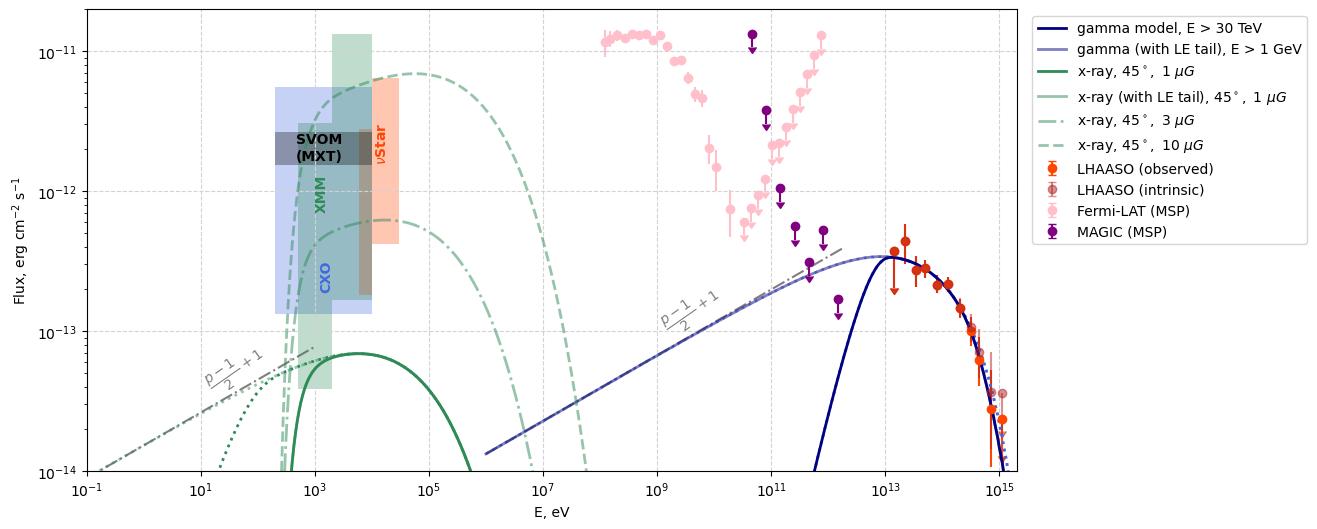

In [60]:
plt.figure(figsize=(12, 6))
ax = plt.gca()

plot_lhaaso(ax)
plot_gamma_rays(ax)
plot_xrays(ax)
plot_powerlaws(ax)
plot_fermi_magic(ax)

# CHANDRA (CXO)
# https://chandra.harvard.edu/about/specs.html
fl_cxo = 4e-15 * eflux_unit_erg
psf_cxo = 1 * u.arcsec
e1_cxo, e2_cxo = 0.2 * u.keV, 10 * u.keV
cxo_smin = xray_sensitivity(fl_cxo, psf_cxo, e1_cxo, e2_cxo, psf_cxo)
cxo_smax = xray_sensitivity(fl_cxo, psf_cxo, e1_cxo, e2_cxo, 0.5 * u.deg)
ax.fill_between([e1_cxo.to_value(u.eV), e2_cxo.to_value(u.eV)],
                cxo_smin.to_value(eflux_unit_erg) * np.ones(2),
                cxo_smax.to_value(eflux_unit_erg) * np.ones(2),
                color='royalblue', alpha=.3, linewidth=0)
ax.text(1.2e3, 2e-13, "CXO", weight='bold', rotation=90, color='royalblue')

# NuStar
# https://heasarc.gsfc.nasa.gov/docs/nustar/nustar_tech_desc.html
fl_nustar = np.array([2e-15, 1e-14]) * eflux_unit_erg
psfs_nustar = 18 * u.arcsec / 2.331  # fwhm -> sigma
e1_nustar, e2_nustar = np.array([6, 10]) * u.keV, np.array([10, 30]) * u.keV
nustar_smin = xray_sensitivity(fl_nustar, psfs_nustar, e1_nustar, e2_nustar, psfs_nustar)
nustar_smax = xray_sensitivity(fl_nustar, psfs_nustar, e1_nustar, e2_nustar, 0.5 * u.deg)

ax.fill_between([e1_nustar[0].to_value(u.eV), e2_nustar[0].to_value(u.eV)],
                nustar_smin[0].to_value(eflux_unit_erg) * np.ones(2),
                nustar_smax[0].to_value(eflux_unit_erg) * np.ones(2),
                color='orangered', alpha=.3, linewidth=0)
ax.fill_between([e1_nustar[1].to_value(u.eV), e2_nustar[1].to_value(u.eV)],
                nustar_smin[1].to_value(eflux_unit_erg) * np.ones(2),
                nustar_smax[1].to_value(eflux_unit_erg) * np.ones(2),
                color='orangered', alpha=.3, linewidth=0)
ax.text(np.sqrt(e1_nustar * e2_nustar)[1].to_value(u.eV)/1.5,
        np.sqrt(nustar_smin * nustar_smax)[1].to_value(eflux_unit_erg),
        r"$\nu$Star", weight='bold', rotation=90, color='orangered')

# XMM-Newton
fl_xmm = np.array([2e-15, 1e-14]) * eflux_unit_erg
psfs_xmm = 6*u.arcsec / 2.331
e1_xmm, e2_xmm = np.array([0.5, 2]) * u.keV, np.array([2, 10]) * u.keV
xmm_smin = xray_sensitivity(fl_xmm, psfs_nustar, e1_xmm, e2_xmm, psfs_xmm)
xmm_smax = xray_sensitivity(fl_xmm, psfs_xmm, e1_xmm, e2_xmm, 0.5 * u.deg)

ax.fill_between([e1_xmm[0].to_value(u.eV), e2_xmm[0].to_value(u.eV)],
                xmm_smin[0].to_value(eflux_unit_erg) * np.ones(2),
                xmm_smax[0].to_value(eflux_unit_erg) * np.ones(2),
                color='seagreen', alpha=.3, linewidth=0)
ax.fill_between([e1_xmm[1].to_value(u.eV), e2_xmm[1].to_value(u.eV)],
                xmm_smin[1].to_value(eflux_unit_erg) * np.ones(2),
                xmm_smax[1].to_value(eflux_unit_erg) * np.ones(2),
                color='seagreen', alpha=.3, linewidth=0)
ax.text(np.sqrt(e1_xmm * e2_xmm)[0].to_value(u.eV),
        np.sqrt(xmm_smin * xmm_smax)[1].to_value(eflux_unit_erg)/2,
        r"XMM", weight='bold', rotation=90, color='seagreen')

# SVOM
# https://heasarc.gsfc.nasa.gov/docs/heasarc/missions/svom.html
fl_svom = 150e-6 / np.sqrt(10) * 2.4e-8 * eflux_unit_erg  # 150 uCrab @ 10 ks -> std units @100 ks
psf_svom = 10 * u.arcmin
e1_svom, e2_svom = 0.2 * u.keV, 10 * u.keV
svom_smin = xray_sensitivity(fl_svom, psf_svom, e1_svom, e2_svom, psf_svom)
svom_smax = xray_sensitivity(fl_svom, psf_svom, e1_svom, e2_svom, 0.5 * u.deg)
ax.fill_between([e1_svom.to_value(u.eV), e2_svom.to_value(u.eV)],
                svom_smin.to_value(eflux_unit_erg) * np.ones(2),
                svom_smax.to_value(eflux_unit_erg) * np.ones(2),
                color='black', alpha=.3, linewidth=0)
ax.text(np.sqrt(e1_svom * e2_svom).to_value(u.eV)/3,
        np.sqrt(svom_smin * svom_smax).to_value(eflux_unit_erg)/1.2,
        "SVOM\n(MXT)", weight='bold', color='black')

# ADJUSTMENTS
adjust_plot(ax)
ax.set_ylim(1e-14, 2e-11)

plt.legend(loc=1, ncol=1, fontsize=10, bbox_to_anchor = (1.32, 1.0))
#plt.tight_layout()
plt.show()